In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [2]:
# Muat dataset iris dari file CSV/data
dataset = pd.read_csv('http://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data', header=None, sep=',')
# Menyusun data X (fitur) dan y (label)
X = dataset.iloc[:, :-1].values # 4 kolom pertama sebagai fitur
y = dataset.iloc[:,-1].values # Kolom terakhir sebagai label

In [3]:
# Mengonversi label dari string menjadi numerik
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y) # Mengubah label jadi 0, 1, 2

In [4]:
# Memisahkan dataset menjadi data latih dan data validasi dengan rasio 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2, random_state=42)

In [5]:
model = Sequential([
    Input(shape=X_train.shape[1:]),
    Dense(1000, activation='relu'),
    Dense(500, activation='relu'),
    Dense(300, activation='relu'),
    Dense(3, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1000)           │         5,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 300)            │       150,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 656,703 (2.51 MB)

 Trainable params: 656,703 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 507ms/step - accuracy: 0.4333 - loss: 1.0128 - val_accuracy: 0.6333 - val_loss: 0.7325
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6583 - loss: 0.6184 - val_accuracy: 0.7000 - val_loss: 0.4905
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7417 - loss: 0.4568 - val_accuracy: 0.6333 - val_loss: 0.4475
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7167 - loss: 0.4389 - val_accuracy: 0.7667 - val_loss: 0.3572
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7500 - loss: 0.3731 - val_accuracy: 0.8333 - val_loss: 0.3197
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9250 - loss: 0.2853 - val_accuracy: 0.9667 - val_loss: 0.2344
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9417 - loss: 0.2115 - val_accuracy: 0.8333 - val_loss: 0.2825
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9417 - loss: 0.2127 - val_accuracy: 0.8000 - val_loss: 0.2715

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8667 - loss: 0.2046
Loss: 0.20459212362766266, Accuracy: 0.8666666746139526


<Axes: >

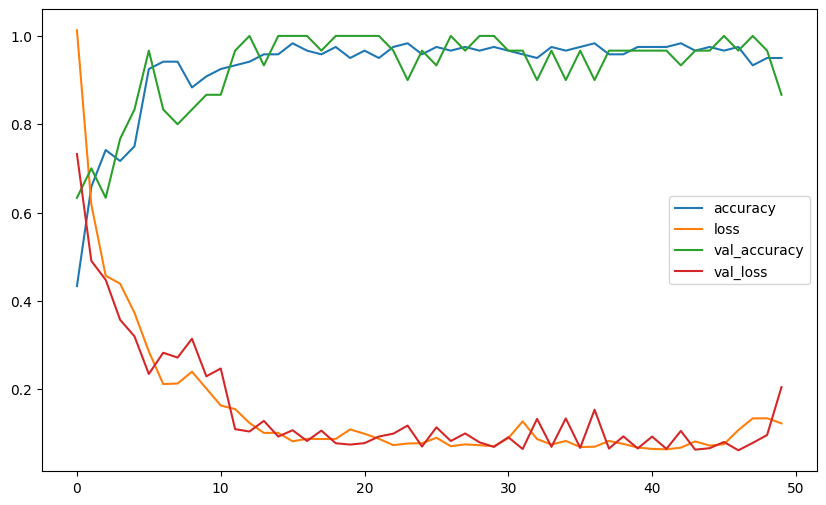

In [8]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss: {loss}, Accuracy: {accuracy}")
pd.DataFrame(history.history).plot(figsize=(10,6))

<Axes: >

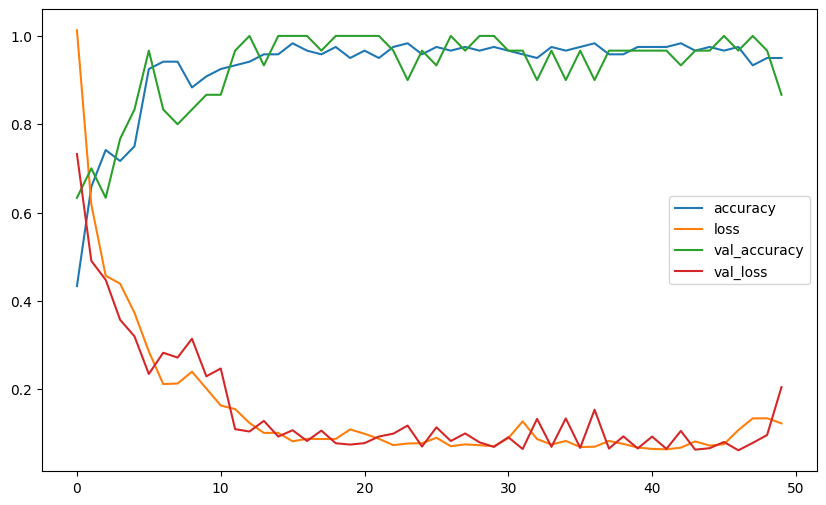

In [9]:
pd.DataFrame(history.history).plot(figsize=(10,6))

In [10]:
predictions = model.predict(X_test)
# Mengambil indeks dari nilai probabilitas tertinggi untuk setiap prediksi
predicted_classes = predictions.argmax(axis=1)

print("Prediksi:", predicted_classes)
print("Label Asli:", y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
Prediksi: [1 0 2 1 1 0 1 1 1 1 1 0 0 0 0 1 2 1 1 2 0 1 0 2 1 2 2 2 0 0]
Label Asli: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


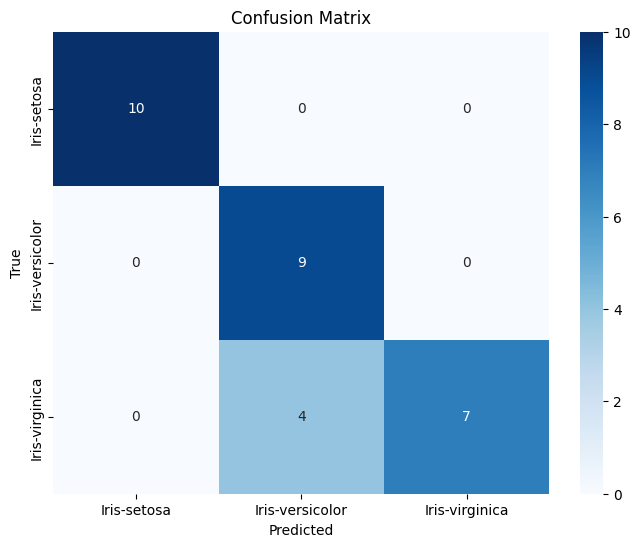

In [11]:
# Buat confusion matrix
cm = confusion_matrix(y_test, predicted_classes)
# Visualisasikan confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Fungsi untuk memprediksi data input baru
def predict_new_data():
    sepal_length = float(input("Masukkan sepal length: "))
    sepal_width = float(input("Masukkan sepal width: "))
    petal_length = float(input("Masukkan petal length: "))
    petal_width = float(input("Masukkan petal width: "))
    # Membuat data array baru
    new_data = np.array([[sepal_length, sepal_width, petal_length,
    petal_width]])
    # Melakukan prediksi
    prediction = model.predict(new_data)
    predicted_class = prediction.argmax(axis=1)
    # Mengonversi hasil prediksi numerik menjadi label asli
    predicted_label = label_encoder.inverse_transform(predicted_class)
    print(f"Prediksi kelas: {predicted_label[0]}")
    
predict_new_data()